# Tesla Deliveries: End-to-End Machine Learning Pipeline

## 1: Data Ingestion & Preprocessing

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn import metrics
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Set visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
# 1. Check for missing values and duplicates
print("--- Data Quality Checks ---")
print("Missing values in each column:")
print(df.isnull().sum())
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

--- Data Quality Checks ---
Missing values in each column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Number of duplicate rows: 0


In [4]:
# 2. Date Alignment: Parse Year and Month into a proper Date object
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values('Date').reset_index(drop=True)

In [5]:
# 3. Summary statistics
print("\n--- Dataset Descriptive Statistics ---")
df.describe()


--- Dataset Descriptive Statistics ---


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712,2020-06-16 02:10:54.545454
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000,2015-01-01 00:00:00
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000,2017-09-23 12:00:00
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000,2020-06-16 00:00:00
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000,2023-03-08 18:00:00
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000,2025-12-01 00:00:00
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883,NaN


## 2: Exploratory Data Analysis (EDA)

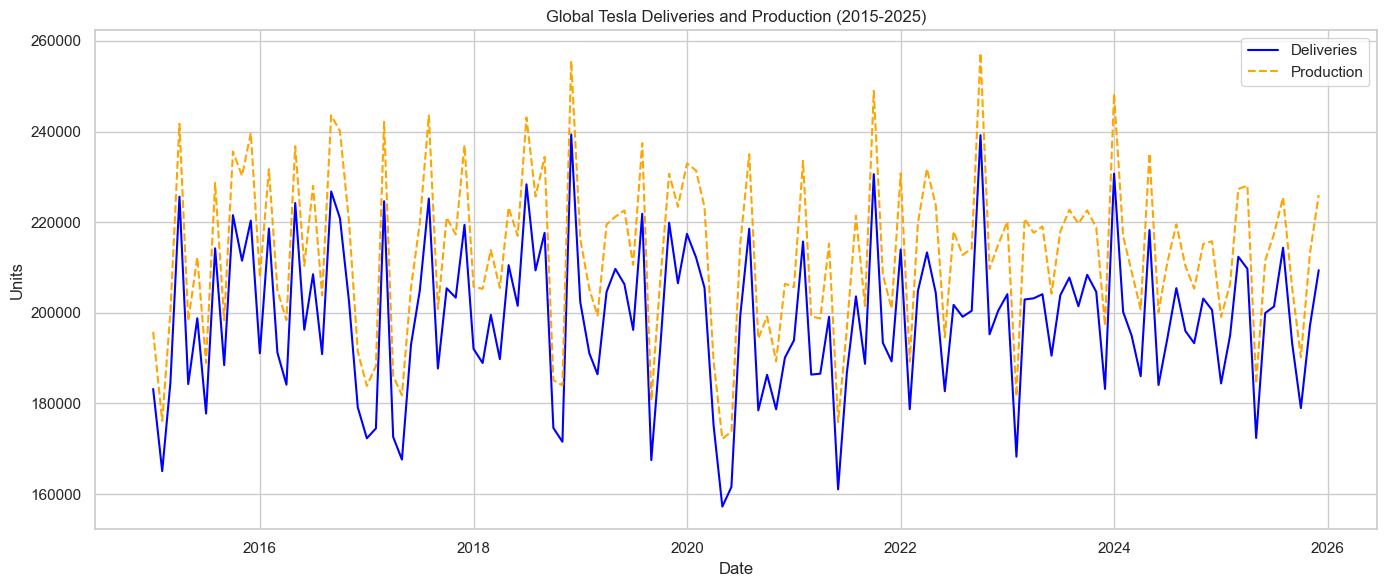

In [6]:
# Plot 1: Global Monthly Deliveries & Production over time
global_metrics = df.groupby('Date')[['Estimated_Deliveries', 'Production_Units']].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=global_metrics, x='Date', y='Estimated_Deliveries', label='Deliveries', color='blue')
sns.lineplot(data=global_metrics, x='Date', y='Production_Units', label='Production', color='orange', linestyle='--')
plt.title('Global Tesla Deliveries and Production (2015-2025)')
plt.ylabel('Units')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

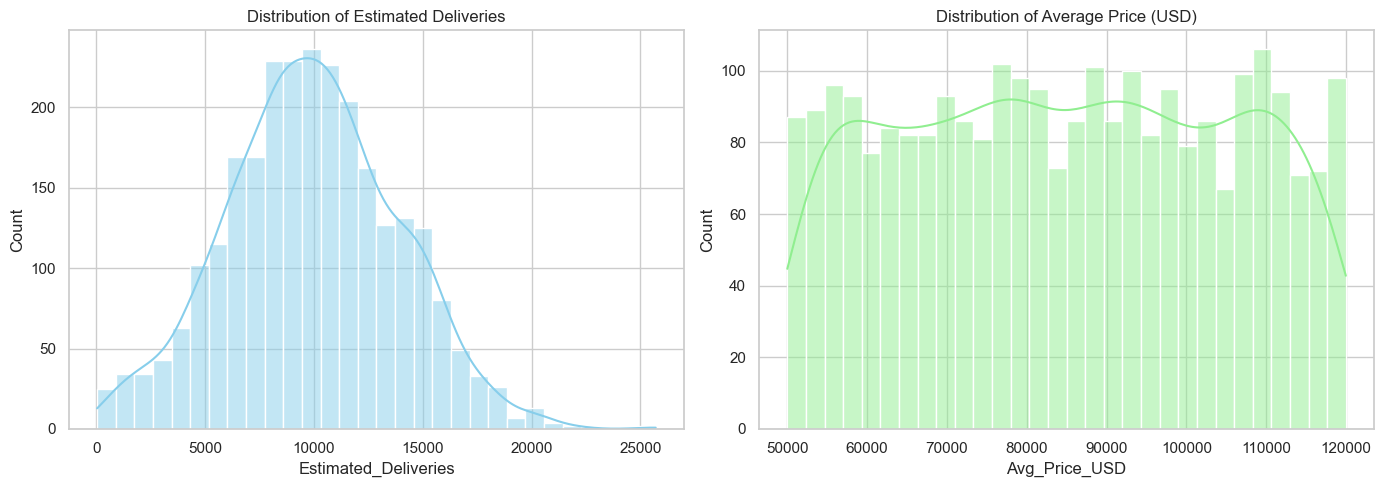

In [7]:
# Plot 2: Distribution of Target (Deliveries) and Price
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Estimated_Deliveries'], bins=30, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Estimated Deliveries')

sns.histplot(df['Avg_Price_USD'], bins=30, kde=True, ax=ax[1], color='lightgreen')
ax[1].set_title('Distribution of Average Price (USD)')
plt.tight_layout()
plt.show()

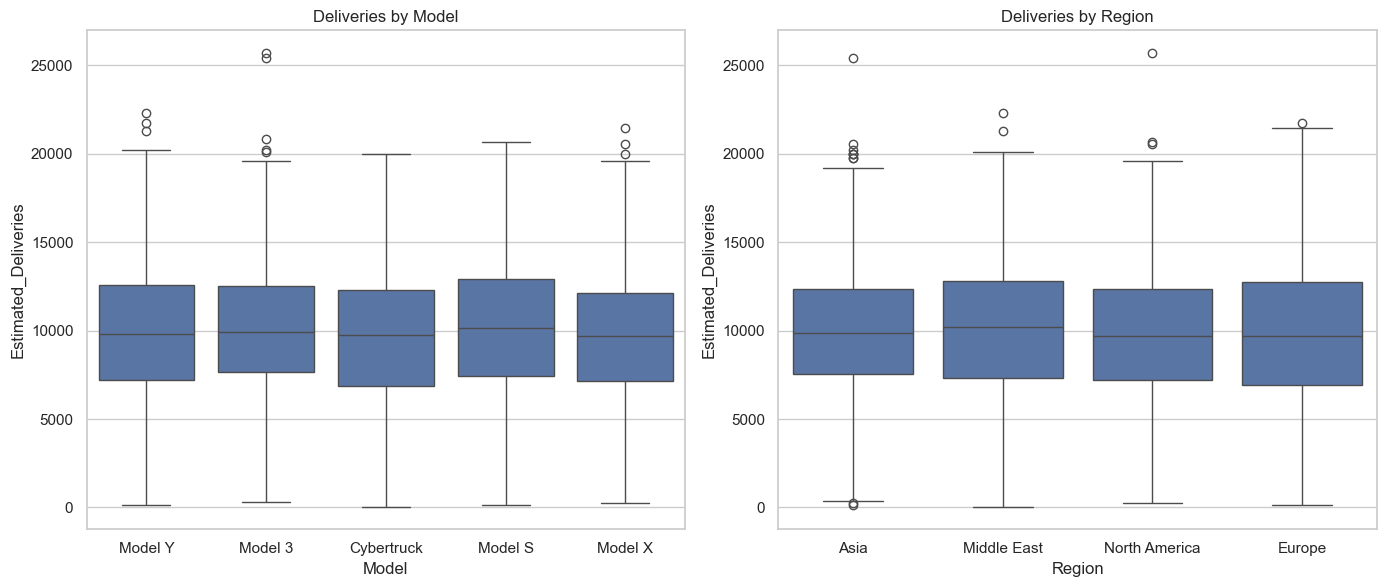

In [8]:
# Plot 3: Deliveries by Model and Region
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df, x='Model', y='Estimated_Deliveries', ax=ax[0])
ax[0].set_title('Deliveries by Model')

sns.boxplot(data=df, x='Region', y='Estimated_Deliveries', ax=ax[1])
ax[1].set_title('Deliveries by Region')
plt.tight_layout()
plt.show()

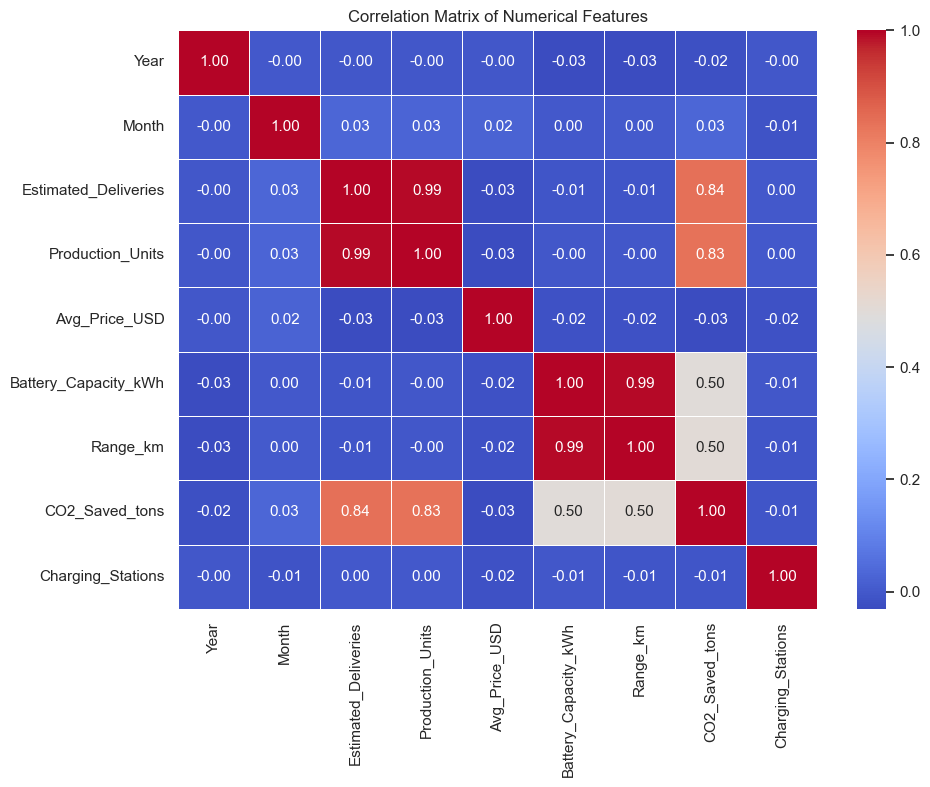

In [9]:
# Plot 4: Correlation Matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## 3: Feature Preprocessing & Engineering 

In [10]:
# Create basic interaction features
df_feat = df.copy()
df_feat['Price_per_Range'] = df_feat['Avg_Price_USD'] / df_feat['Range_km']
df_feat['Price_per_Battery'] = df_feat['Avg_Price_USD'] / df_feat['Battery_Capacity_kWh']

# Create Lag and Rolling features group by Region and Model
df_feat = df_feat.sort_values(['Region', 'Model', 'Date'])

# Lag features
df_feat['Deliveries_Lag1'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df_feat['Deliveries_Lag2'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(2)
df_feat['Deliveries_Lag12'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(12)

# Rolling features (calculated on shifted data to prevent leakage)
df_feat['Deliveries_Roll3'] = df_feat.groupby(['Region', 'Model'])['Deliveries_Lag1'].transform(lambda x: x.rolling(window=3).mean())
df_feat['Deliveries_Roll6'] = df_feat.groupby(['Region', 'Model'])['Deliveries_Lag1'].transform(lambda x: x.rolling(window=6).mean())

df_feat = df_feat.sort_values('Date').reset_index(drop=True)

# Drop rows with NaN values generated by lag/rolling
df_feat = df_feat.dropna().reset_index(drop=True)
print(f"Dataset shape after feature engineering and dropping NaNs: {df_feat.shape}")

Dataset shape after feature engineering and dropping NaNs: (2400, 20)


## 4: Chronological Train-Test Split

In [11]:
# Chronological Split
train_mask = df_feat['Date'] < '2024-01-01'
test_mask = df_feat['Date'] >= '2024-01-01'

train_df = df_feat[train_mask]
test_df = df_feat[test_mask]

print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")

Training set size: 1920
Testing set size: 480


In [12]:
# Define features and target
target = 'Estimated_Deliveries'
categorical_features = ['Region', 'Model', 'Source_Type']
# Include original numerics + new engineered features
numerical_features = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 
                      'CO2_Saved_tons', 'Charging_Stations', 'Price_per_Range', 'Price_per_Battery', 
                      'Deliveries_Lag1', 'Deliveries_Lag2', 'Deliveries_Lag12', 'Deliveries_Roll3', 'Deliveries_Roll6']

X_train = train_df[categorical_features + numerical_features]
y_train = train_df[target]

X_test = test_df[categorical_features + numerical_features]
y_test = test_df[target]

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

## 5: Regression Modeling & Hyperparameter Tuning

We will evaluate three powerful tree-based ensemble models:
1. **Random Forest Regressor**
2. **Gradient Boosting Regressor**
3. **XGBoost Regressor**

We'll use `GridSearchCV` combined with `TimeSeriesSplit` to optimize their hyperparameters without violating time constraints.

In [13]:
# Define TimeSeriesSplit for CV
tscv = TimeSeriesSplit(n_splits=3)

# 1. Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
rf_param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, None]
}
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
print("Training Random Forest...")
rf_grid.fit(X_train, y_train)
print("Training complete.")

Training Random Forest...
Training complete.


In [14]:
# 2. Gradient Boosting
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])
gb_param_grid = {
    'model__n_estimators': [50, 100],
    'model__learning_rate': [0.05, 0.1]
}
gb_grid = GridSearchCV(gb_pipeline, gb_param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
print("Training Gradient Boosting...")
gb_grid.fit(X_train, y_train)
print("Training complete.")


Training Gradient Boosting...
Training complete.


In [15]:
# 3. XGBoost
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))
])
xgb_param_grid = {
    'model__n_estimators': [50, 100],
    'model__learning_rate': [0.05, 0.1]
}
xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
print("Training XGBoost...")
xgb_grid.fit(X_train, y_train)
print("Training complete.")

Training XGBoost...
Training complete.


In [16]:
# Evaluate Models
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = metrics.mean_absolute_error(y_test, preds)
    mse = metrics.mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(y_test, preds)
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate_model('Random Forest', rf_grid.best_estimator_, X_test, y_test))
results.append(evaluate_model('Gradient Boosting', gb_grid.best_estimator_, X_test, y_test))
results.append(evaluate_model('XGBoost', xgb_grid.best_estimator_, X_test, y_test))

results_df = pd.DataFrame(results)
print(results_df)

               Model         MAE            MSE        RMSE        R2
0      Random Forest  340.948024  177076.915117  420.805080  0.987249
1  Gradient Boosting  334.724895  166481.737592  408.021737  0.988012
2            XGBoost  286.761383  126474.289062  355.632239  0.990893


#### From the above results we can conclude that XGBoost performs well in comparision to the other models. 

## 6: Time Series Forecasting (ARIMA & SARIMA)

In [17]:
# Aggregate global deliveries by month
ts_df = df_feat.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
ts_df = ts_df.set_index('Date') 
ts_df.index = pd.DatetimeIndex(ts_df.index).to_period('M')

# Split into train and validation (leave 2025 out)

ts_train = ts_df[ts_df.index < '2025-01']
ts_test = ts_df[ts_df.index >= '2025-01']

print(f"Time Series Train length: {len(ts_train)}")
print(f"Time Series Test length: {len(ts_test)}")

# 1. ARIMA Model
print("\nFitting ARIMA Model...")
arima_model =ARIMA(ts_train, order=(1, 1, 1))
arima_result = arima_model.fit()
print(arima_result.summary().tables[1])

# 2. SARIMA Model
print("\nFitting SARIMA Model...")
# Add seasonal order (p,d,q,s) where s=12 for yearly seasonality
sarima_model = SARIMAX(ts_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary().tables[1])

Time Series Train length: 108
Time Series Test length: 12

Fitting ARIMA Model...
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3750      0.057      6.631      0.000       0.264       0.486
ma.L1         -0.9643      0.042    -23.045      0.000      -1.046      -0.882
sigma2      3.804e+08   4.07e-11   9.35e+18      0.000     3.8e+08     3.8e+08

Fitting SARIMA Model...
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1599      0.204      0.784      0.433      -0.240       0.560
ma.L1         -0.5283      0.172     -3.076      0.002      -0.865      -0.192
ar.S.L12       0.2336      0.102      2.295      0.022       0.034       0.433
ma.S.L12      -0.8712      0.225     -3.880      0.000      -1.311      -0.431
sigma2      6.264e+08   

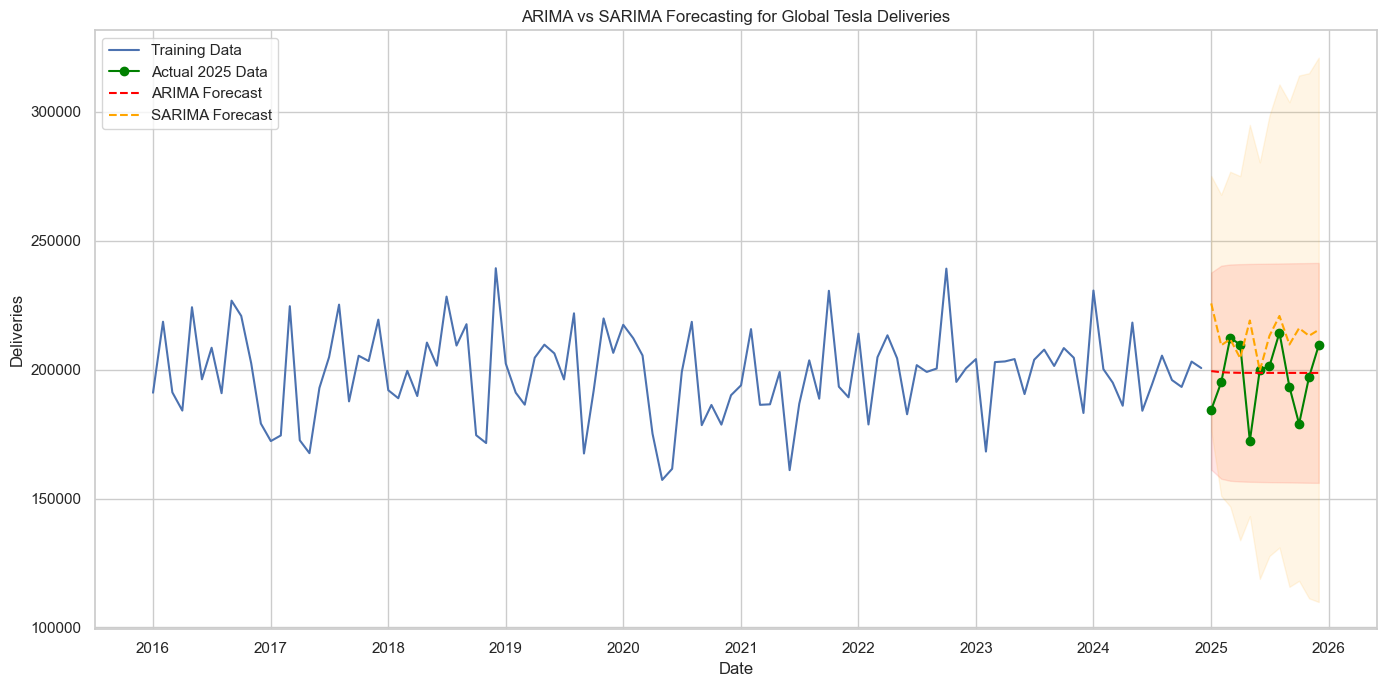

In [18]:
# Forecasting and Plotting
steps = len(ts_test)

# ARIMA Forecast
arima_forecast = arima_result.get_forecast(steps=steps)
arima_mean = arima_forecast.predicted_mean
arima_ci = arima_forecast.conf_int()

# SARIMA Forecast
sarima_forecast = sarima_result.get_forecast(steps=steps)
sarima_mean = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

# Plot
plt.figure(figsize=(14, 7))
plt.plot(ts_train.index.to_timestamp(), ts_train['Estimated_Deliveries'], label='Training Data')
plt.plot(ts_test.index.to_timestamp(), ts_test['Estimated_Deliveries'], label='Actual 2025 Data', color='green', marker='o')

# ARIMA
plt.plot(arima_mean.index.to_timestamp(), arima_mean, label='ARIMA Forecast', color='red', linestyle='--')
plt.fill_between(arima_ci.index.to_timestamp(), arima_ci.iloc[:, 0], arima_ci.iloc[:, 1], color='red', alpha=0.1)

# SARIMA
plt.plot(sarima_mean.index.to_timestamp(), sarima_mean, label='SARIMA Forecast', color='orange', linestyle='--')
plt.fill_between(sarima_ci.index.to_timestamp(), sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='orange', alpha=0.1)

plt.title('ARIMA vs SARIMA Forecasting for Global Tesla Deliveries')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.show()